## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors


# Esto es para que las gráficas se vean bien en el notebook
%matplotlib inline

from sklearn.linear_model import LinearRegression


> ## **Nota aclaratoria:**
>La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Laboratorio

> ### 1. Construya un DataFrame de pandas con un conjunto de datos lineales simples.

In [2]:
X_datos = np.array([1, 2, 3, 4, 5])
y_datos = np.array([2, 4, 6, 8, 10])

df = pd.DataFrame({'X': X_datos, 'Y': y_datos})

print("Nuestro DataFrame:")
display(df)

Nuestro DataFrame:


,X,Y
0,1,2
1,2,4
2,3,6
3,4,8
4,5,10


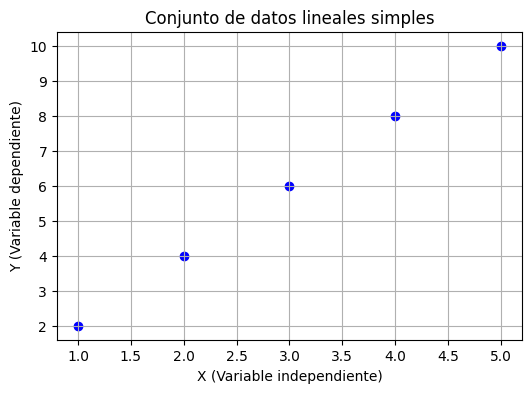

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['Y'], color='blue', marker='o')
plt.title('Conjunto de datos lineales simples')
plt.xlabel('X (Variable independiente)')
plt.ylabel('Y (Variable dependiente)')
plt.grid(True)
plt.show()

> ### 2. Deﬁna una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

En regresión lineal, nuestro objetivo es encontrar una recta que pase lo más cerca posible de todos los puntos de nuestro conjunto de datos. Esta recta, también llamada **hipótesis**, se define como:

$$h_\theta(X) = \theta_0 + \theta_1X$$

Para saber qué tan buena es nuestra recta, necesitamos una métrica que mida el error entre nuestras predicciones y los valores reales. Esta métrica es la **Función de Coste** (o Error Cuadrático Medio), y se define en la ecuación (1) del laboratorio como:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Donde:
* **$m$**: Es la cantidad total de datos de entrenamiento.
* **$h_\theta(x^{(i)})$**: Es el valor que predice nuestro modelo.
* **$y^{(i)}$**: Es el valor real de los datos.
* Se divide por **$2m$** (en lugar de solo $m$) para facilitar las matemáticas más adelante cuando calculemos la derivada en el gradiente descendente (el exponente 2 se cancelará con el 2 del denominador).

A continuación, traducimos esta formulación matemática a una función en Python empleando operaciones vectorizadas con `numpy`.

In [4]:
def funcion_coste(X, y, theta_0, theta_1):
    """
    Calcula la función de coste cuadrática para la regresión lineal.
    """
    m = len(y)

    predicciones = theta_0 + theta_1 * X

    errores = predicciones - y

    errores_cuadrados = errores ** 2

    coste = (1 / (2 * m)) * np.sum(errores_cuadrados)

    return coste

coste_perfecto = funcion_coste(df['X'], df['Y'], theta_0=0, theta_1=2)
print(f"Coste con theta_0=0 y theta_1=2: {coste_perfecto}")

coste_malo = funcion_coste(df['X'], df['Y'], theta_0=0, theta_1=0)
print(f"Coste con theta_0=0 y theta_1=0: {coste_malo}")

Coste con theta_0=0 y theta_1=2: 0.0
Coste con theta_0=0 y theta_1=0: 22.0


> ### 3. Fijando inicialmente $\theta_0 = 0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y graﬁque la recta obtenida sobre los datos.

Para entender visualmente cómo se comporta la función de coste, vamos a simplificar nuestro modelo temporalmente. Si fijamos el parámetro $\theta_0$ (el punto de corte con el eje Y) en $0$, nuestra recta siempre pasará por el origen y la ecuación de nuestra hipótesis se reduce a:

$$h_\theta(X) = \theta_1X$$

Ahora la función de coste depende de un solo parámetro ($\theta_1$). Matemáticamente, al sustituir esta hipótesis en la fórmula del error cuadrático, el resultado es una ecuación cuadrática o de segundo grado. Al graficarla, deberíamos observar una **parábola**.

El punto más bajo de esta parábola (el valle) representa el valor de $\theta_1$ donde el error es mínimo. Nuestro objetivo es encontrar gráficamente ese punto, extraer el valor óptimo de $\theta_1$, y luego usar ese valor para graficar la recta final sobre nuestros datos originales.

El valor óptimo de theta_1 encontrado es: 2.00
El coste mínimo asociado es: 0.0001


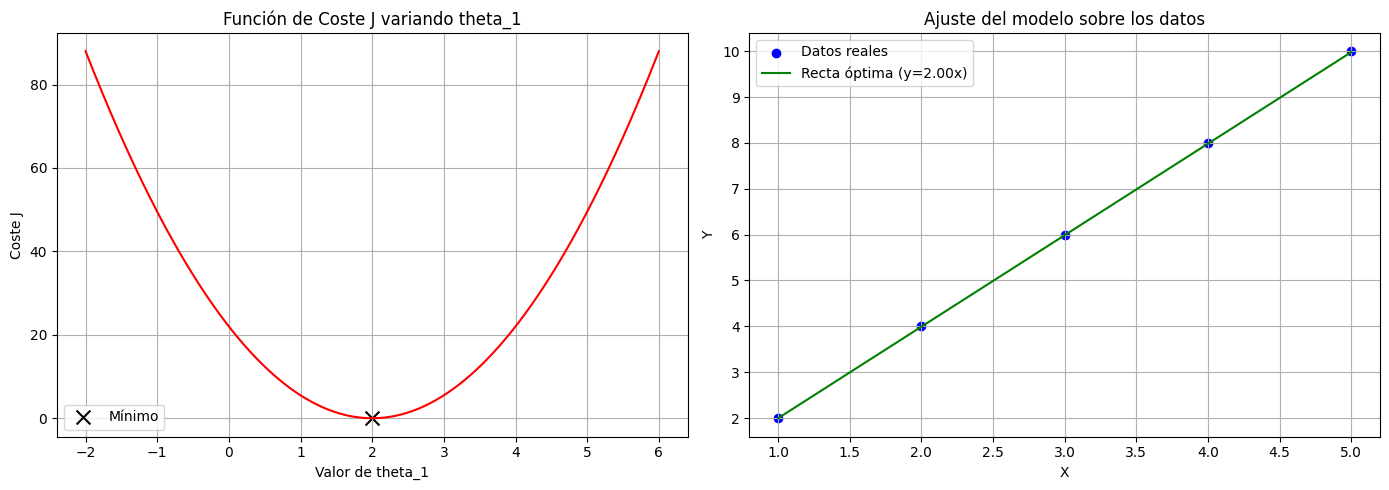

In [5]:
theta_0_fijo = 0
theta_1_valores = np.linspace(-2, 6, 1000)

costes =[]
for t1 in theta_1_valores:
    coste_actual = funcion_coste(df['X'], df['Y'], theta_0_fijo, t1)
    costes.append(coste_actual)

indice_minimo = np.argmin(costes)
theta_1_optimo = theta_1_valores[indice_minimo]
coste_minimo = costes[indice_minimo]

print(f"El valor óptimo de theta_1 encontrado es: {theta_1_optimo:.2f}")
print(f"El coste mínimo asociado es: {coste_minimo:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(theta_1_valores, costes, color='red')
ax1.scatter([theta_1_optimo], [coste_minimo], color='black', marker='x', s=100, label='Mínimo')
ax1.set_title('Función de Coste J variando theta_1')
ax1.set_xlabel('Valor de theta_1')
ax1.set_ylabel('Coste J')
ax1.legend()
ax1.grid(True)

predicciones_optimas = theta_0_fijo + theta_1_optimo * df['X']

ax2.scatter(df['X'], df['Y'], color='blue', label='Datos reales')
ax2.plot(df['X'], predicciones_optimas, color='green', label=f'Recta óptima (y={theta_1_optimo:.2f}x)')
ax2.set_title('Ajuste del modelo sobre los datos')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Análisis de la gráfica:**

* **Gráfica de la izquierda:** Como predijimos, la función de coste forma una parábola convexa. El algoritmo de búsqueda (en este caso manual) encontró correctamente que el punto más bajo está exactamente en $\theta_1 = 2$.
* **Gráfica de la derecha:** Al sustituir $\theta_1 = 2$ y $\theta_0 = 0$ en nuestra ecuación lineal, obtenemos una línea verde que pasa exactamente por el centro de todos nuestros puntos azules. El error es cero porque los datos que creamos son perfectamente lineales.

> ### 4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, evalúe la función de coste en cada punto y represente su superﬁcie y curvas de nivel.



En la realidad, un modelo de regresión lineal simple necesita optimizar simultáneamente dos parámetros: el intercepto ($\theta_0$) y la pendiente ($\theta_1$). Como nuestra función de coste ahora depende de dos variables independientes, su representación gráfica ya no es una línea en 2D, sino una **superficie en 3D**.

Para evaluar y graficar esto, usamos el concepto matemático de una "malla" o cuadrícula (implementado mediante `np.meshgrid`). Evaluaremos la función de coste en cada intersección de esa cuadrícula.

Visualizaremos los resultados de dos formas:
1. **Gráfico de Superficie (3D):** Nos permite ver el relieve tridimensional del error.
2. **Mapa de Contorno o Curvas de Nivel (2D):** Es una representación plana (como un mapa topográfico). Cada línea o "anillo" conecta puntos que tienen exactamente el mismo valor de coste.

El centro de esos anillos representará el punto más profundo de nuestro "valle" de errores, es decir, el **mínimo global**.

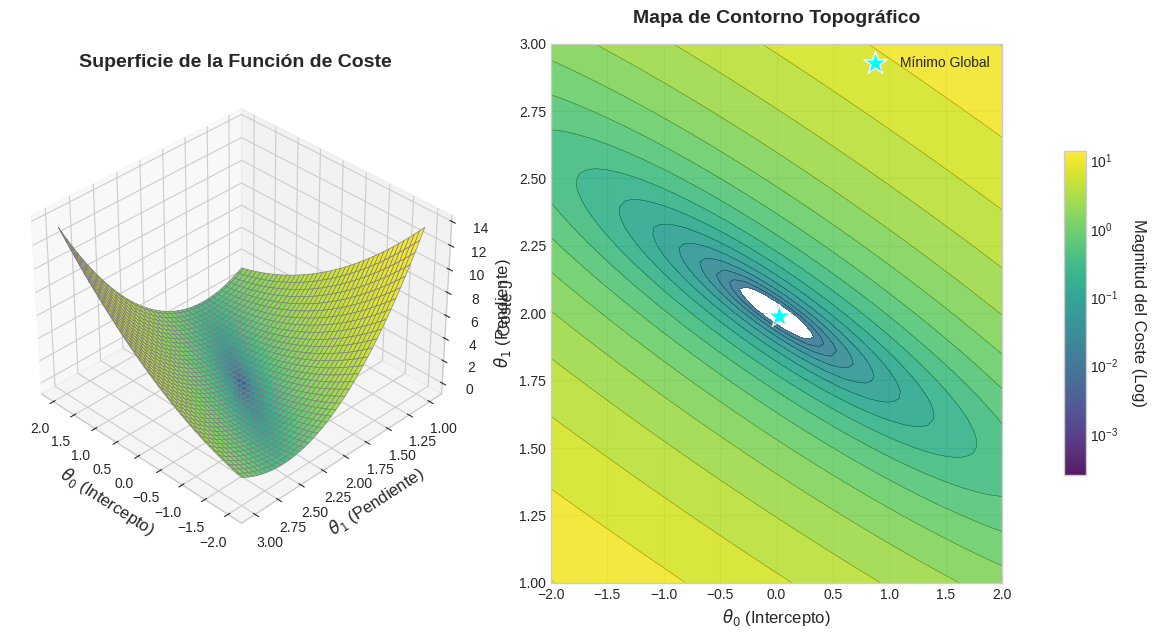

In [6]:
theta0_valores = np.linspace(-2, 2, 80)
theta1_valores = np.linspace(1, 3, 80)

T0, T1 = np.meshgrid(theta0_valores, theta1_valores)
J_vals = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = funcion_coste(df['X'], df['Y'], T0[i, j], T1[i, j])

min_idx = np.unravel_index(np.argmin(J_vals, axis=None), J_vals.shape)
theta0_optimo_3d, theta1_optimo_3d, coste_minimo_3d = T0[min_idx], T1[min_idx], J_vals[min_idx]

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 7))

norm = colors.LogNorm(vmin=J_vals.min() + 1e-5, vmax=J_vals.max())
# Cambiamos la paleta de colores a 'plasma'
cmap_elegido = 'viridis'

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(T0, T1, J_vals, cmap=cmap_elegido, norm=norm,
                        linewidth=0.5, edgecolors='gray', alpha=0.9)

# Usamos color cian para la estrella para que contraste con el morado oscuro
ax1.scatter([theta0_optimo_3d],[theta1_optimo_3d],[coste_minimo_3d],
            color='cyan', marker='*', s=300, edgecolor='white', label='Mínimo Global')
ax1.set_title('Superficie de la Función de Coste', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel(r'$\theta_0$ (Intercepto)', fontsize=12)
ax1.set_ylabel(r'$\theta_1$ (Pendiente)', fontsize=12)
ax1.set_zlabel('Coste J', fontsize=12)

# Cambiamos la orientación de la cámara (Elevación y Rotación)
ax1.view_init(elev=35, azim=135)

ax2 = fig.add_subplot(1, 2, 2)
cont_fill = ax2.contourf(T0, T1, J_vals, levels=np.logspace(-2, 3, 25), cmap=cmap_elegido, norm=norm, alpha=0.85)
ax2.contour(T0, T1, J_vals, levels=np.logspace(-2, 3, 25), colors='black', linewidths=0.3, alpha=0.5)

ax2.scatter(theta0_optimo_3d, theta1_optimo_3d, color='cyan', marker='*', s=300, edgecolor='white', label='Mínimo Global')

ax2.set_title('Mapa de Contorno Topográfico', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel(r'$\theta_0$ (Intercepto)', fontsize=12)
ax2.set_ylabel(r'$\theta_1$ (Pendiente)', fontsize=12)
ax2.legend(loc='upper right')

cbar = fig.colorbar(surf, ax=[ax1, ax2], shrink=0.6, aspect=15, pad=0.05)
cbar.set_label('Magnitud del Coste (Log)', fontsize=12, rotation=270, labelpad=20)

plt.show()
plt.style.use('default')

> ### 5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

**Interpretación Geométrica de los resultados:**

1. **Forma convexa de la superficie (Gráfica 3D):** La función de coste forma una superficie en forma de "cuenco" o tazón parabólico. En términos matemáticos, esta es una **función estrictamente convexa**. La gran ventaja de las funciones convexas en el aprendizaje automático es que garantizan matemáticamente que cualquier mínimo local es también el mínimo global. Es decir, el algoritmo del Gradiente Descendente nunca se quedará "atascado" en un valle falso; siempre rodará hacia el fondo absoluto.

2. **Las curvas de nivel (Gráfica 2D):** Tienen forma de elipses concéntricas. Cada elipse representa un conjunto de combinaciones de $(\theta_0, \theta_1)$ que producen exactamente el mismo error. A medida que avanzamos hacia el centro de las elipses, el error disminuye.

3. **El Mínimo Global:** Geométricamente, el mínimo global es el fondo exacto del tazón en 3D, y el punto central de todas las elipses en el mapa de contorno. Como muestran los resultados de nuestro código, este punto central se ubica exactamente en las coordenadas $(\theta_0 = 0, \theta_1 = 2)$, lo cual tiene total sentido lógico ya que nuestros datos fueron generados por la ecuación $Y = 0 + 2X$.

> ### 6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

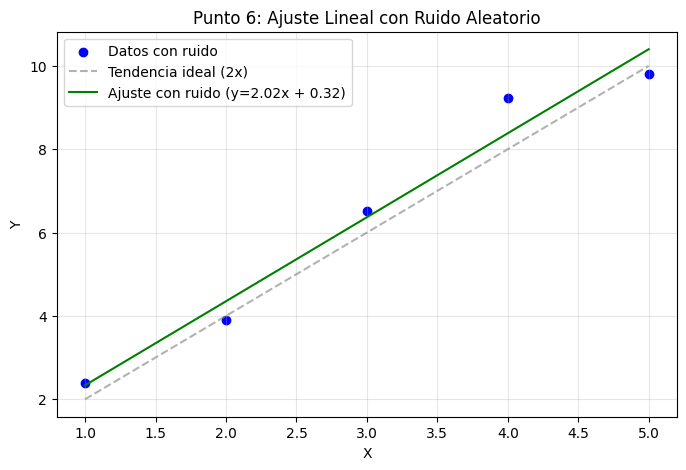

Coste mínimo (Caso Ideal): 0.0000
Coste mínimo (Caso con Ruido): 0.1282


In [7]:
np.random.seed(42)
X_6 = np.array([1, 2, 3, 4, 5])
y_ideal = 2 * X_6

# Añadimos ruido aleatorio
ruido = np.random.normal(0, 0.8, size=len(X_6))
y_ruido = y_ideal + ruido

# Calculamos los parámetros óptimos para los datos con ruido
theta1_r, theta0_r = np.polyfit(X_6, y_ruido, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_6, y_ruido, color='blue', label='Datos con ruido')
plt.plot(X_6, y_ideal, color='gray', linestyle='--', alpha=0.6, label='Tendencia ideal (2x)')
plt.plot(X_6, theta0_r + theta1_r * X_6, color='green', label=f'Ajuste con ruido (y={theta1_r:.2f}x + {theta0_r:.2f})')
plt.title('Punto 6: Ajuste Lineal con Ruido Aleatorio')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

coste_ideal = funcion_coste(X_6, y_ideal, 0, 2)
coste_ruido = funcion_coste(X_6, y_ruido, theta0_r, theta1_r)

print(f"Coste mínimo (Caso Ideal): {coste_ideal:.4f}")
print(f"Coste mínimo (Caso con Ruido): {coste_ruido:.4f}")

En este escenario, añadimos una pequeña perturbación aleatoria (ruido gaussiano) a nuestra relación lineal perfecta. El ruido representa factores externos no controlados o errores de precisión en la toma de datos.

**Análisis teórico:**
Cuando los datos tienen ruido, la función de coste $J(\theta_0, \theta_1)$ sigue siendo convexa (forma de tazón), pero el punto exacto donde se encuentra el mínimo global se desplazará. En el caso ideal, el coste mínimo era $0$. Con ruido, el coste mínimo será **mayor a cero**, ya que es imposible que una sola línea recta pase exactamente por todos los puntos dispersos. La "mejor" recta ahora es aquella que minimiza el promedio de las distancias al cuadrado de todos los puntos.

> ### 7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

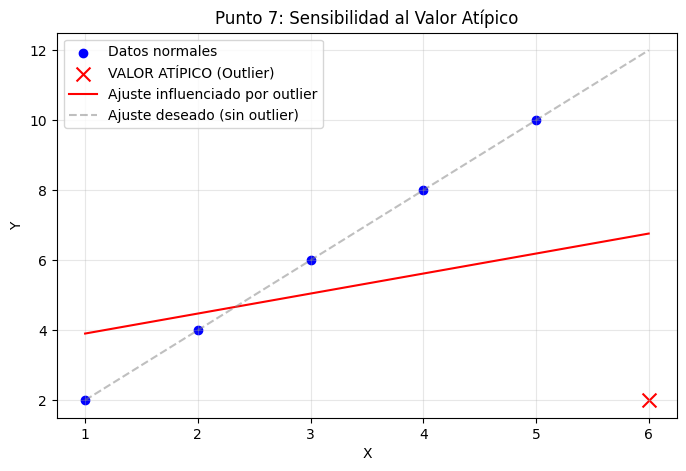

Nueva pendiente (theta_1) con outlier: 0.57 (Debería ser 2.0)
Nuevo intercepto (theta_0) con outlier: 3.33 (Debería ser 0.0)


In [8]:
X_7 = np.array([1, 2, 3, 4, 5, 6])
y_7 = np.array([2, 4, 6, 8, 10, 2]) # El último punto (6, 2) es el outlier

# Ajuste con el outlier incluido
theta1_out, theta0_out = np.polyfit(X_7, y_7, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_7[:-1], y_7[:-1], color='blue', label='Datos normales')
plt.scatter(X_7[-1], y_7[-1], color='red', marker='x', s=100, label='VALOR ATÍPICO (Outlier)')

# Dibujamos la recta resultante
plt.plot(X_7, theta0_out + theta1_out * X_7, color='red', label='Ajuste influenciado por outlier')
plt.plot(X_7, 0 + 2 * X_7, color='gray', linestyle='--', alpha=0.5, label='Ajuste deseado (sin outlier)')

plt.title('Punto 7: Sensibilidad al Valor Atípico')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Nueva pendiente (theta_1) con outlier: {theta1_out:.2f} (Debería ser 2.0)")
print(f"Nuevo intercepto (theta_0) con outlier: {theta0_out:.2f} (Debería ser 0.0)")


Un valor atípico o *outlier* es un dato que se aleja drásticamente de la tendencia general del resto de la muestra.

**Análisis de limitaciones:**
La función de coste cuadrática tiene una característica matemática crítica: eleva el error al cuadrado: $(h_\theta(x) - y)^2$.
* Si un punto normal tiene un error de $2$, su contribución al coste es $4$.
* Si un outlier tiene un error de $10$, su contribución al coste es **$100$**.

Debido a esto, el algoritmo "sufre" mucho por ese único punto y trata de compensarlo moviendo la recta hacia el outlier para reducir ese error masivo. El resultado es que la recta se "inclina" hacia la anomalía, perjudicando el ajuste de todos los demás puntos que sí eran correctos. Decimos que la función de coste cuadrática **no es robusta** ante valores atípicos.

> ### 8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

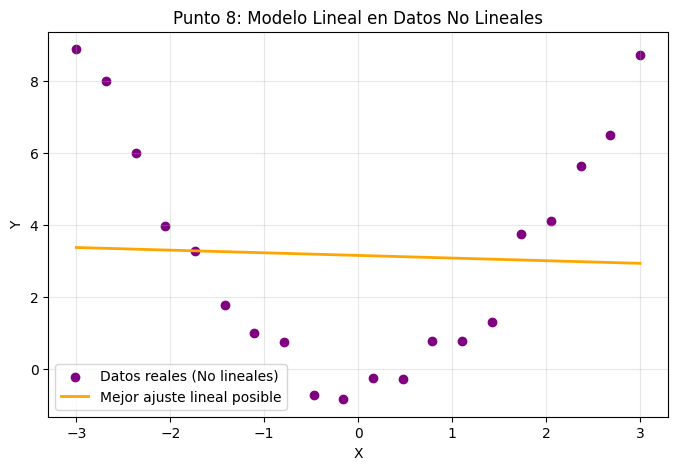

In [9]:
X_8 = np.linspace(-3, 3, 20)
# Relación cuadrática: y = x^2
y_8 = X_8**2 + np.random.normal(0, 0.5, 20)

# Intentamos ajustar una RECTA a esta CURVA
theta1_nl, theta0_nl = np.polyfit(X_8, y_8, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_8, y_8, color='purple', label='Datos reales (No lineales)')
plt.plot(X_8, theta0_nl + theta1_nl * X_8, color='orange', linewidth=2, label='Mejor ajuste lineal posible')

plt.title('Punto 8: Modelo Lineal en Datos No Lineales')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En este caso, intentaremos ajustar una línea recta a datos que siguen una estructura curva (cuadrática).

**Discusión sobre la adecuación:**
Es fundamental entender que **minimizar la función de coste NO garantiza que el modelo sea bueno**. El optimizador (gradiente descendente) siempre encontrará la "mejor línea recta", es decir, la que tenga el menor error posible *dentro de las limitaciones de ser una recta*.

Sin embargo, si la naturaleza de los datos es curva, una línea recta siempre será un modelo pobre. Esto se conoce como **Subajuste (Underfitting)**: el modelo es demasiado simple para capturar la complejidad de los datos. Minimizar el coste es solo un paso técnico; la validación visual y métricas adicionales son necesarias para confirmar si la arquitectura del modelo (lineal en este caso) es la correcta para el problema.

> ## 9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

Para entender la geometría de lo que hemos graficado, debemos expandir algebraicamente la sumatoria de la función de coste.

> ### A. Caso con un parámetro ($\theta_0 = 0$)

Si fijamos el intercepto en cero, la función depende solo de la pendiente $\theta_1$. La expresión es:
$$J(\theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (\theta_1 x^{(i)} - y^{(i)})^2$$

Al expandir el binomio al cuadrado dentro de la sumatoria:
$$J(\theta_1) = \frac{1}{2m} \sum_{i=1}^{m} [ (x^{(i)})^2 \theta_1^2 - 2(x^{(i)}y^{(i)}) \theta_1 + (y^{(i)})^2 ]$$

Si separamos los términos, observamos que tiene la forma de una ecuación cuadrática clásica $f(z) = az^2 + bz + c$:
$$J(\theta_1) = \underbrace{\left( \frac{\sum (x^{(i)})^2}{2m} \right)}_{a} \theta_1^2 - \underbrace{\left( \frac{\sum x^{(i)}y^{(i)}}{m} \right)}_{b} \theta_1 + \underbrace{\left( \frac{\sum (y^{(i)})^2}{2m} \right)}_{c}$$

**Interpretación:** Esta es la razón por la cual la gráfica del Punto 3 es una **parábola**. El coeficiente $a$ siempre es positivo (suma de cuadrados), lo que garantiza que la parábola abre hacia arriba y tiene un único punto mínimo.

> ### B. Caso con dos parámetros ($\theta_0, \theta_1$)

Al permitir ambos parámetros, la expresión se convierte en una forma cuadrática bivariada:
$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (\theta_0 + \theta_1 x^{(i)} - y^{(i)})^2$$

Al expandir esta expresión, obtenemos términos con $\theta_0^2$, $\theta_1^2$ y el término cruzado $\theta_0\theta_1$. En álgebra lineal, esto se representa como una superficie parabólica o **paraboloide elíptico**.

> ### C. Significado de sus mínimos

El mínimo de la función de coste representa el **Estado de Máxima Verosimilitud** o el ajuste de **Mínimos Cuadrados**.

1. **Matemáticamente:** Es el punto donde las derivadas parciales de la función con respecto a los parámetros son iguales a cero ($\nabla J = 0$).
2. **Estadísticamente:** Es el punto donde la varianza del error no explicada por el modelo es la menor posible.
3. **Geométricamente:** Es el "centro de gravedad" del error. En este punto, la recta resultante equilibra las distancias hacia todos los puntos, de modo que la suma de los errores por encima de la línea se compensa con la suma de los errores por debajo (minimizando sus cuadrados).

# Parte 2: Gradiente descendente

El **Gradiente Descendente** es un algoritmo de optimización iterativo. Su objetivo es encontrar el mínimo de una función siguiendo la dirección de la pendiente más pronunciada hacia abajo.

**¿Cómo funciona?**
Imagina que estás en la cima de una montaña en medio de una niebla espesa. No puedes ver el fondo, pero puedes sentir la inclinación del suelo bajo tus pies. Para bajar, das pasos en la dirección donde el suelo baja más rápido.

Matemáticamente, esto se rige por la ecuación (3) del laboratorio:
$$\omega_{i+1} = \omega_i - \alpha \frac{df(\omega_i)}{d\omega}$$

Donde:
* **$\omega$**: Es el parámetro que queremos optimizar (en este caso, la variable $x$).
* **$\alpha$ (Tasa de aprendizaje/Learning Rate)**: Es el tamaño del paso. Si es muy pequeño, tardaremos mucho en llegar. Si es muy grande, podríamos "saltar" el mínimo y nunca encontrarlo.
* **$\frac{df(\omega_i)}{d\omega}$ (Derivada/Gradiente)**: Indica la dirección y la fuerza de la pendiente.



> ### 10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función.


Para este ejercicio, optimizaremos la función:
$$f(x) = (x - 4)^2$$
Cuya derivada analítica es:
$$f'(x) = 2(x - 4)$$

El algoritmo se detendrá cuando el cambio entre un paso y otro sea menor a un error $\epsilon = 10^{-4}$.

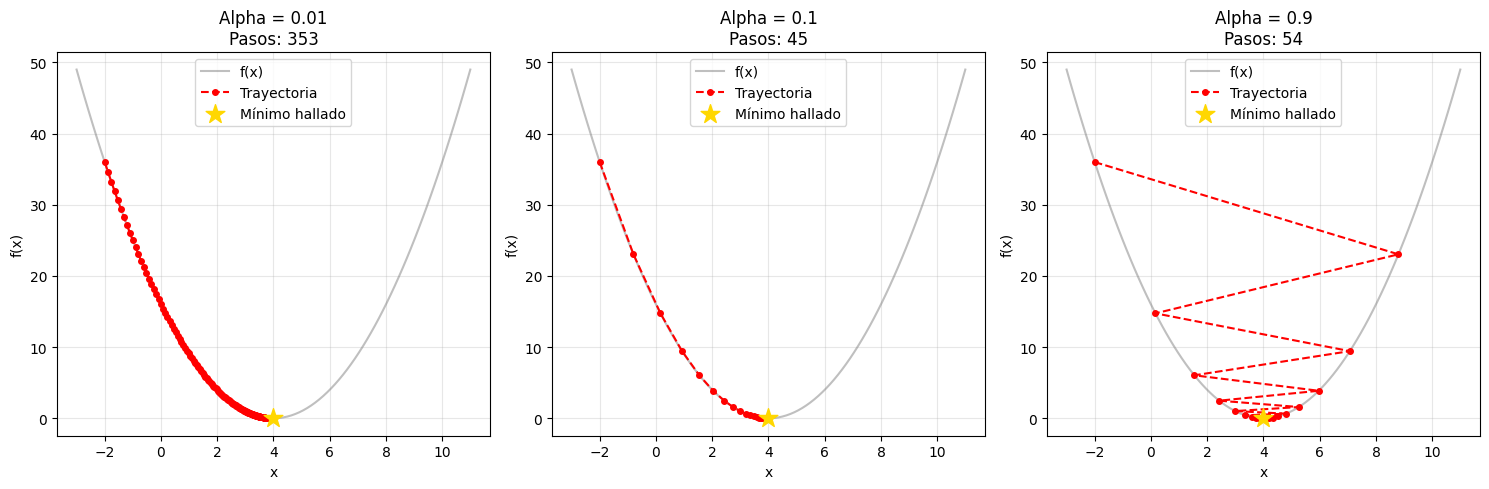

Resultado final con alpha 0.1: x = 3.9999 (El valor real es 4.0)


In [10]:
def gradiente_descendente_1d(x_inicial, alpha, epsilon, max_iter=1000):
    """
    Implementación del Gradiente Descendente para f(x) = (x-4)^2
    """
    x_actual = x_inicial
    historial_x = [x_actual]
    historial_coste = [(x_actual - 4)**2]

    for i in range(max_iter):
        # Calculamos la derivada en el punto actual: f'(x) = 2(x - 4)
        gradiente = 2 * (x_actual - 4)

        # Aplicamos la regla de actualización
        x_siguiente = x_actual - alpha * gradiente

        # Guardamos para graficar después
        historial_x.append(x_siguiente)
        historial_coste.append((x_siguiente - 4)**2)

        # Verificamos criterio de parada (tolerancia de error epsilon)
        if abs(x_siguiente - x_actual) < epsilon:
            break

        x_actual = x_siguiente

    return x_actual, historial_x, historial_coste

# --- PRUEBA CON DIFERENTES TASAS DE APRENDIZAJE (alpha) ---
alphas = [0.01, 0.1, 0.9] # Pequeño, Ideal, Muy grande
x_inicio = -2
epsilon = 1e-4

plt.figure(figsize=(15, 5))
x_plot = np.linspace(-3, 11, 100)
y_plot = (x_plot - 4)**2

for i, a in enumerate(alphas):
    x_min, h_x, h_c = gradiente_descendente_1d(x_inicio, a, epsilon)

    plt.subplot(1, 3, i+1)
    plt.plot(x_plot, y_plot, color='gray', alpha=0.5, label='f(x)')
    plt.plot(h_x, h_c, color='red', marker='o', markersize=4, linestyle='--', label='Trayectoria')
    plt.scatter(x_min, (x_min-4)**2, color='gold', marker='*', s=200, zorder=5, label='Mínimo hallado')

    plt.title(f'Alpha = {a}\nPasos: {len(h_x)}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Resultado final con alpha 0.1: x = {x_min:.4f} (El valor real es 4.0)")

**Análisis de los resultados:**

* **Alpha pequeño (0.01):** El algoritmo es muy cauteloso. Da pasos minúsculos y requiere muchos pasos para llegar al mínimo (puedes ver muchos puntos rojos juntos). Es seguro pero lento.
* **Alpha ideal (0.1):** Los pasos son más grandes al principio (donde la pendiente es fuerte) y se vuelven pequeños al acercarse al mínimo. Llega rápidamente al valor óptimo ($x=4$).
* **Alpha grande (0.9):** En este caso, el paso es tan grande que el algoritmo "rebota" de un lado a otro de la parábola antes de converger. Si el valor de alpha fuera mayor a $1.0$ en esta función específica, el algoritmo divergiría (los pasos serían cada vez más grandes y se alejaría al infinito).

Este comportamiento es idéntico a lo que sucede cuando entrenamos redes neuronales o regresiones lineales complejas.

> ### 11. Encontrar el mínimo de la función $F(x, y)$ a través del método del gradiente descendente.

Ahora subiremos el nivel de complejidad. Optimizaremos una función que depende de dos variables ($x$ e $y$) y que incluye funciones trigonométricas y exponenciales:

$$F(x, y) = \sin\left(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3\right) \cos(2x + 1 - e^y)$$

**El Gradiente en 2D:**
Para descender en una superficie, ya no nos basta con una sola derivada. Necesitamos el **Vector Gradiente** ($\nabla F$), que contiene las derivadas parciales respecto a cada variable:

$$\nabla F(x, y) = \begin{bmatrix} \frac{\partial F}{\partial x} \\ \frac{\partial F}{\partial y} \end{bmatrix}$$

La regla de actualización se convierte en una operación vectorial:
$$\begin{bmatrix} x \\ y \end{bmatrix}_{new} = \begin{bmatrix} x \\ y \end{bmatrix}_{old} - \alpha \nabla F(x, y)$$

Primero, visualizaremos la superficie para entender a qué nos enfrentamos y elegir un punto de partida lógico.

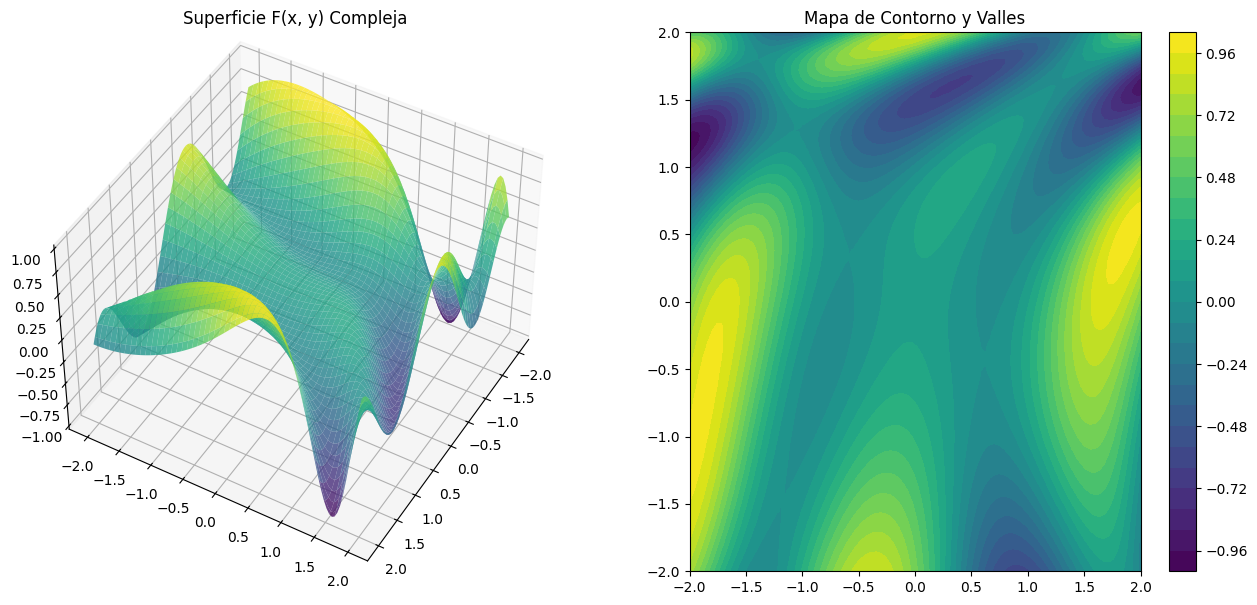

In [11]:
# Definimos la función matemática compleja
def F(x, y):
    term1 = np.sin(0.5 * x**2 - 0.25 * y**2 + 3)
    term2 = np.cos(2 * x + 1 - np.exp(y))
    return term1 * term2

# Creamos la malla para graficar
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X_m, Y_m = np.meshgrid(x_range, y_range)
Z_m = F(X_m, Y_m)

# Graficamos la superficie y el mapa de contorno
fig = plt.figure(figsize=(16, 7))

# Superficie 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X_m, Y_m, Z_m, cmap='viridis', alpha=0.8)
ax1.set_title('Superficie F(x, y) Compleja')
ax1.view_init(elev=45, azim=30)

# Mapa de Contorno
ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contourf(X_m, Y_m, Z_m, levels=30, cmap='viridis')
fig.colorbar(cont, ax=ax2)
ax2.set_title('Mapa de Contorno y Valles')

plt.show()

**Cálculo del Gradiente Numérico:**
Dada la complejidad de derivar analíticamente esta función, utilizaremos una **aproximación numérica**. El gradiente en un punto se puede calcular viendo cuánto cambia la función ante un paso muy pequeño ($h$) en cada dirección:

$$\frac{\partial F}{\partial x} \approx \frac{F(x+h, y) - F(x, y)}{h}$$

In [12]:
def gradiente_numerico(f, x, y, h=1e-7):
    """Calcula el gradiente aproximado de f en (x, y)"""
    df_dx = (f(x + h, y) - f(x, y)) / h
    df_dy = (f(x, y + h) - f(x, y)) / h
    return np.array([df_dx, df_dy])

def gradiente_descendente_2d(f, punto_inicio, alpha, iteraciones):
    """Algoritmo de optimización para funciones de dos variables"""
    punto = np.array(punto_inicio)
    historial = [punto.copy()]
    
    for _ in range(iteraciones):
        grad = gradiente_numerico(f, punto[0], punto[1])
        punto = punto - alpha * grad
        historial.append(punto.copy())
        
    return punto, np.array(historial)

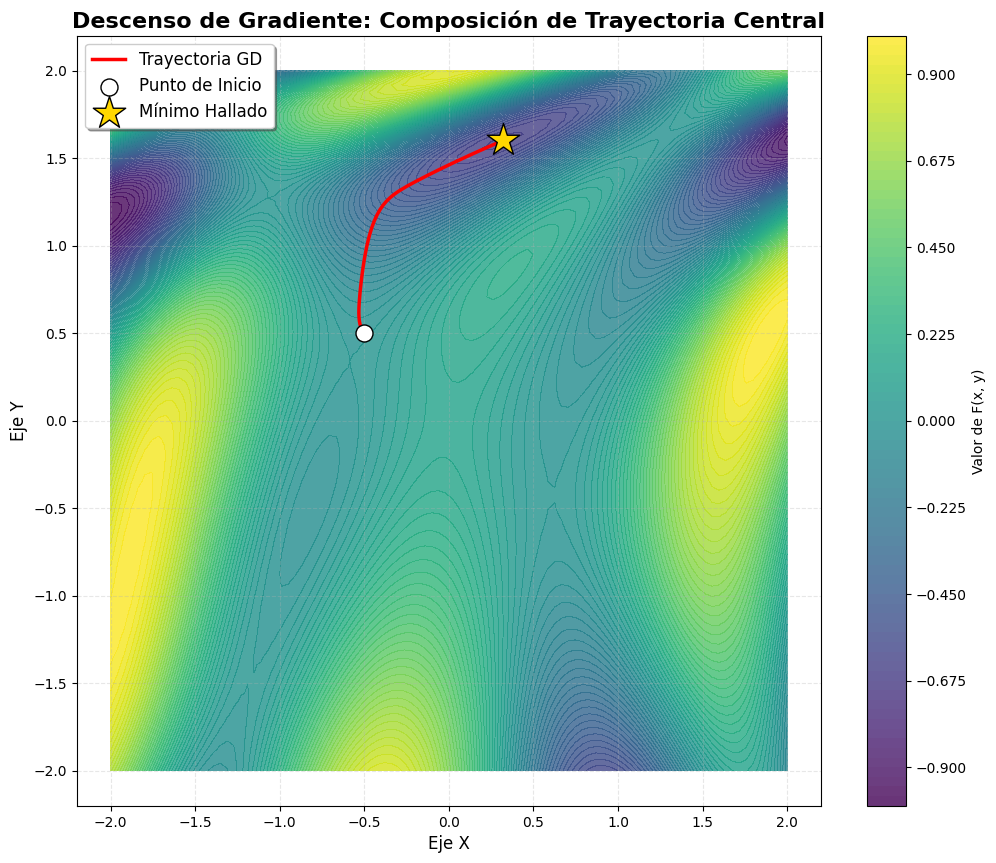

Coordenadas del mínimo central: x = 0.3227, y = 1.6024


In [13]:
# --- AJUSTE DE PARÁMETROS PARA COMPOSICIÓN VISUAL ---
punto_inicial = [-0.5, 0.5]  # Nuevo inicio para caer en un valle más central
alpha_optimo = 0.05
max_iteraciones = 1000

# Ejecutamos el descenso
punto_min, camino = gradiente_descendente_2d(F, punto_inicial, alpha_optimo, max_iteraciones)

# --- GRÁFICO CON MARGENES (PADDING) ---
plt.figure(figsize=(12, 10))

# Mantenemos la alta resolución de contornos y la paleta viridis
cont = plt.contourf(X_m, Y_m, Z_m, levels=80, cmap='viridis', alpha=0.8)
plt.colorbar(cont, label='Valor de F(x, y)')

# Trayectoria en rojo vibrante
plt.plot(camino[:, 0], camino[:, 1], color='red', linewidth=2.5, label='Trayectoria GD', zorder=3)

# Marcadores con borde para resaltar
plt.scatter(camino[0, 0], camino[0, 1], color='white', edgecolors='black',
            s=150, marker='o', label='Punto de Inicio', zorder=4)

# La estrella dorada ahora tendrá espacio de sobra
plt.scatter(camino[-1, 0], camino[-1, 1], color='gold', edgecolors='black',
            s=600, marker='*', label='Mínimo Hallado', zorder=5)

plt.title('Descenso de Gradiente: Composición de Trayectoria Central', fontsize=16, fontweight='bold')
plt.xlabel('Eje X', fontsize=12)
plt.ylabel('Eje Y', fontsize=12)

# AMPLIAMOS LOS LÍMITES (Padding) para que nada toque el borde
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(f"Coordenadas del mínimo central: x = {camino[-1, 0]:.4f}, y = {camino[-1, 1]:.4f}")

# Parte 3: Modelo de machine learning: solución general

> ### 12. Construcción del algoritmo de Regresión Lineal



Para aplicar el Gradiente Descendente a la Regresión Lineal, necesitamos las derivadas parciales de nuestra función de coste $J(\theta_0, \theta_1)$. Estas derivadas nos indican cuánto debe cambiar cada parámetro para reducir el error.

Según las ecuaciones (9) y (10) del laboratorio, las reglas de actualización son:

1. **Para el intercepto ($\theta_0$):**
$$\theta_0 := \theta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$$

2. **Para la pendiente ($\theta_1$):**
$$\theta_1 := \theta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}$$

Usaremos los datos proporcionados en la guía: una línea con una pendiente de $0.2$, un intercepto de $0.2$ y un ruido aleatorio muy leve. El objetivo de nuestro algoritmo es "descubrir" estos valores originales a partir de los datos ruidosos.

In [14]:
# Generación de datos según la guía
np.random.seed(42)
X_reg = np.linspace(0, 1, 100)
# y = 0.2 + 0.2*x + ruido
y_reg = 0.2 + 0.2 * X_reg + 0.02 * np.random.random(100)

# Implementación del entrenamiento por Gradiente Descendente
def entrenar_regresion_lineal(X, y, alpha, iteraciones):
    m = len(y)
    # Inicializamos parámetros en cero
    theta_0 = 0.0
    theta_1 = 0.0

    historial_coste = []

    for i in range(iteraciones):
        # Predicción actual (hipótesis)
        h = theta_0 + theta_1 * X

        # Cálculo del error
        error = h - y

        # Cálculo del gradiente (Derivadas parciales)
        grad_theta_0 = (1/m) * np.sum(error)
        grad_theta_1 = (1/m) * np.sum(error * X)

        # Actualización simultánea de parámetros
        theta_0 = theta_0 - alpha * grad_theta_0
        theta_1 = theta_1 - alpha * grad_theta_1

        # Guardamos el coste para ver el progreso
        coste = (1/(2*m)) * np.sum(error**2)
        historial_coste.append(coste)

    return theta_0, theta_1, historial_coste

# --- EJECUCIÓN DEL ENTRENAMIENTO ---
alpha_reg = 0.1
iteraciones_reg = 1000

t0_final, t1_final, costos = entrenar_regresion_lineal(X_reg, y_reg, alpha_reg, iteraciones_reg)

print(f"Valores encontrados por nuestro algoritmo:")
print(f"Intercepto (theta_0): {t0_final:.4f} (Esperado: ~0.2)")
print(f"Pendiente  (theta_1): {t1_final:.4f} (Esperado: ~0.2)")

Valores encontrados por nuestro algoritmo:
Intercepto (theta_0): 0.2092 (Esperado: ~0.2)
Pendiente  (theta_1): 0.2003 (Esperado: ~0.2)


> ### 11. Comparación con la librería `sklearn`



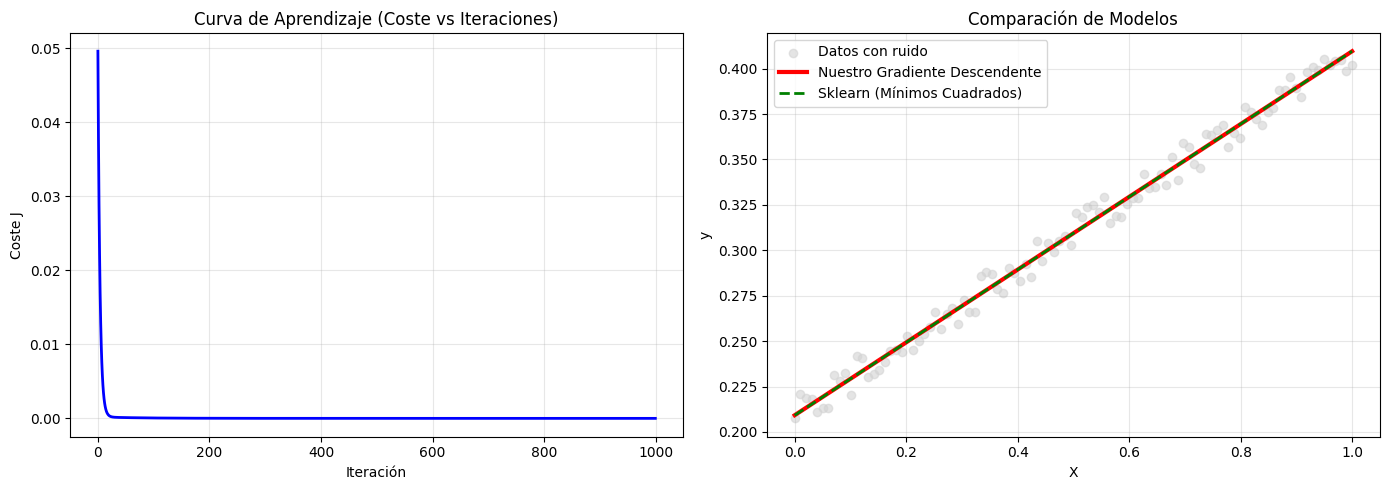

Diferencia en Intercepto: 0.00004402
Diferencia en Pendiente: 0.00008214


In [15]:
# Preparar datos para sklearn (necesita formato de matriz 2D para X)
X_sk = X_reg.reshape(-1, 1)
modelo_sk = LinearRegression()
modelo_sk.fit(X_sk, y_reg)

t0_sk = modelo_sk.intercept_
t1_sk = modelo_sk.coef_[0]

# --- VISUALIZACIÓN DE RESULTADOS ---
plt.figure(figsize=(14, 5))

# Subplot 1: Curva de aprendizaje
plt.subplot(1, 2, 1)
plt.plot(costos, color='blue', linewidth=2)
plt.title('Curva de Aprendizaje (Coste vs Iteraciones)')
plt.xlabel('Iteración')
plt.ylabel('Coste J')
plt.grid(True, alpha=0.3)

# Subplot 2: Ajuste final
plt.subplot(1, 2, 2)
plt.scatter(X_reg, y_reg, color='lightgray', label='Datos con ruido', alpha=0.6)
plt.plot(X_reg, t0_final + t1_final * X_reg, color='red', linewidth=3, label='Nuestro Gradiente Descendente')
plt.plot(X_reg, t0_sk + t1_sk * X_reg, color='green', linestyle='--', linewidth=2, label='Sklearn (Mínimos Cuadrados)')

plt.title('Comparación de Modelos')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Diferencia en Intercepto: {abs(t0_final - t0_sk):.8f}")
print(f"Diferencia en Pendiente: {abs(t1_final - t1_sk):.8f}")

# Parte 4: Libreria Propia

> • Un ejemplo de ejecución sobre los datos del laboratorio.

Resultado de la librería: Intercepto=0.2092, Pendiente=0.2015


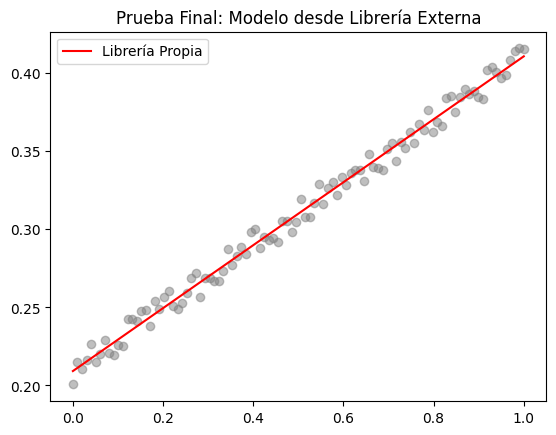

In [16]:
# Importamos las funciones desde nuestra propia librería
from linear_gd_lib.regresion import ajustar_modelo

# Generamos datos de prueba (Punto 12 del lab)
X_test = np.linspace(0, 1, 100)
y_test = 0.2 + 0.2 * X_test + 0.02 * np.random.random(100)

# Entrenamos usando la librería
modelo_final = ajustar_modelo(X_test, y_test, alpha=0.1, iteraciones=1000)

# Extraemos resultados
t0 = modelo_final['theta_0']
t1 = modelo_final['theta_1']
costos = modelo_final['historial_coste']

print(f"Resultado de la librería: Intercepto={t0:.4f}, Pendiente={t1:.4f}")

# Visualización rápida
plt.scatter(X_test, y_test, color='gray', alpha=0.5)
plt.plot(X_test, t0 + t1 * X_test, color='red', label='Librería Propia')
plt.title('Prueba Final: Modelo desde Librería Externa')
plt.legend()
plt.show()